In [1]:
import os
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl
import matplotlib.patches as patches

# =============================================================================
# GLOBAL CONFIGURATION
# =============================================================================
CONFIG = {
    "WORKING_DIR": r"C:\Users\seren\Documents\GitHub\chick\final_project",
    "BEHAV_FILE": "behav_data.xlsx",
    "FRAMES_FILE": "frames_data.xlsx",
    "TARGET_COLUMNS": ['SubID', 'Condition', 'Sex', 'Headshaking', 'Beakwiping', 'Preening', 'Scratching'],
    "BEHAVIORS": ['Headshaking', 'Beakwiping', 'Preening', 'Scratching'],
    "VALID_CONDITIONS": {'A', 'O', 'C'},
    "VALID_SEX": {'M', 'F'},
    "VIDEO_LENGTH_CONSTANT": 5934,
    "PLOT_SETTINGS": {
        "FIGURE_SIZE": (14, 10),
        "CONDITION_PALETTE": {'A': '#0B3C5D', 'O': '#328CC1', 'C': '#D9B310'}, # Dark Blue, Medium Blue, Accent Light
        "SEX_PALETTE": {'M': '#1F77B4', 'F': '#E377C2'} # Clean Blue and Pink contrast
    }
}

# Adjust palette to exact manual requirements (Fixed manual blue gradient vs sex contrast)
CONFIG["PLOT_SETTINGS"]["CONDITION_PALETTE"] = {
    'A': '#0D3B66',  # Dark Blue
    'O': '#4682B4',  # Medium Blue
    'C': '#B0C4DE'   # Light Blue
}

# =============================================================================
# BLOCK 1: RAW DATA LOADING & VALIDATION FUNCTIONS
# =============================================================================

def validate_dataframe(df: pd.DataFrame, file_name: str, config: dict) -> pd.DataFrame:
    """
    Validates the integrity of the imported dataframe against structural rules.
    
    Parameters:
    -----------
    df : pd.DataFrame
        The raw loaded DataFrame.
    file_name : str
        Name of the file (for error reporting).
    config : dict
        The global configuration dictionary.
        
    Returns:
    --------
    pd.DataFrame
        The validated DataFrame clean of minor formatting issues.
    """
    # 1. Verify exact presence of required target columns
    required_cols = config["TARGET_COLUMNS"]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"CRITICAL ERROR in {file_name}: Missing expected columns: {missing_cols}")
    
    # Trim to only the required columns for this pipeline
    df_clean = df[required_cols].copy()
    
    # 2. Check for missing values (NaNs) in the structural or target columns
    if df_clean.isnull().any().any():
        total_nans = df_clean.isnull().sum().sum()
        raise ValueError(f"CRITICAL ERROR in {file_name}: Detected {total_nans} missing value(s). Pipeline halted.")
        
    # 3. Validate categorical factor levels (Condition and Sex)
    # Ensure strings are stripped of unexpected whitespace
    df_clean['Condition'] = df_clean['Condition'].astype(str).str.strip()
    df_clean['Sex'] = df_clean['Sex'].astype(str).str.strip()
    
    observed_conditions = set(df_clean['Condition'].unique())
    observed_sex = set(df_clean['Sex'].unique())
    
    if not observed_conditions.issubset(config["VALID_CONDITIONS"]):
        invalid = observed_conditions - config["VALID_CONDITIONS"]
        raise ValueError(f"CRITICAL ERROR in {file_name}: Invalid 'Condition' categories found: {invalid}")
        
    if not observed_sex.issubset(config["VALID_SEX"]):
        invalid = observed_sex - config["VALID_SEX"]
        raise ValueError(f"CRITICAL ERROR in {file_name}: Invalid 'Sex' categories found: {invalid}")
        
    # 4. Verify metric columns are numerical type
    for behavior in config["BEHAVIORS"]:
        if not np.issubdtype(df_clean[behavior].dtype, np.number):
            raise TypeError(f"CRITICAL ERROR in {file_name}: Column '{behavior}' contains non-numeric data.")
            
    print(f"-> Validation SUCCESSFUL for {file_name}. Shape: {df_clean.shape}")
    return df_clean


def load_and_initialize_pipeline(config: dict) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Changes directory to the working folder, loads Excel files, and runs validation metrics.
    
    Parameters:
    -----------
    config : dict
        The global configuration dictionary.
        
    Returns:
    --------
    tuple[pd.DataFrame, pd.DataFrame]
        A pair of validated dataframes (df_behav, df_frames).
    """
    target_dir = config["WORKING_DIR"]
    
    # Verify directory existence
    if not os.path.exists(target_dir):
        raise FileNotFoundError(f"CRITICAL ERROR: Target directory does not exist:\n{target_dir}")
        
    # Build complete file paths
    behav_path = os.path.join(target_dir, config["BEHAV_FILE"])
    frames_path = os.path.join(target_dir, config["FRAMES_FILE"])
    
    # Verify file existence before loading
    if not os.path.exists(behav_path):
        raise FileNotFoundError(f"Missing file: {behav_path}")
    if not os.path.exists(frames_path):
        raise FileNotFoundError(f"Missing file: {frames_path}")
        
    print(f"Loading files from path: {target_dir}\n")
    
    # Read Excel sheets (ignoring exported_labels.xlsx intentionally)
    raw_df_behav = pd.read_excel(behav_path, engine='openpyxl')
    raw_df_frames = pd.read_excel(frames_path, engine='openpyxl')
    
    # Execute validation functions
    df_behav = validate_dataframe(raw_df_behav, config["BEHAV_FILE"], config)
    df_frames = validate_dataframe(raw_df_frames, config["FRAMES_FILE"], config)
    
    print("\nInitialization Complete. Datasets ready for Descriptive Analysis.")
    return df_behav, df_frames

# Execute Block 1
df_behav, df_frames = load_and_initialize_pipeline(CONFIG)

Loading files from path: C:\Users\seren\Documents\GitHub\chick\final_project

-> Validation SUCCESSFUL for behav_data.xlsx. Shape: (81, 7)
-> Validation SUCCESSFUL for frames_data.xlsx. Shape: (81, 7)

Initialization Complete. Datasets ready for Descriptive Analysis.


In [2]:
def calculate_descriptive_stats_with_combined(df: pd.DataFrame, dataset_name: str, config: dict) -> pd.DataFrame:
    """
    Computes Sample Size (n), Mean, Median, SD, and SEM for target behaviors,
    grouped hierarchically by Condition and Sex (including a combined M+F row).
    
    Parameters:
    -----------
    df : pd.DataFrame
        The validated input DataFrame (df_behav or df_frames).
    dataset_name : str
        A descriptive label for output display headers.
    config : dict
        The global configuration dictionary containing target behaviors.
        
    Returns:
    --------
    pd.DataFrame
        A flattened, cleanly formatted summary table of descriptive metrics.
    """
    behaviors = config["BEHAVIORS"]
    summary_records = []
    
    # Define aggregation metrics using standard ddof=1 for SD/SEM
    agg_funcs = {
        'n': 'count',
        'Mean': 'mean',
        'Median': 'median',
        'SD': 'std',
        'SEM': lambda x: stats.sem(x, ddof=1) if len(x) > 1 else 0.0
    }
    
    for behavior in behaviors:
        # 1. Compute stats split by Condition and Sex (M vs F)
        grouped_sex = df.groupby(['Condition', 'Sex'])[behavior].agg(**agg_funcs).reset_index()
        
        # 2. Compute stats split by Condition only (M + F combined)
        grouped_combined = df.groupby(['Condition'])[behavior].agg(**agg_funcs).reset_index()
        grouped_combined['Sex'] = 'All (M+F)'  # Label explicitly for clarity
        
        # Merge split and combined records for the current behavior
        behavior_summary = pd.concat([grouped_sex, grouped_combined], ignore_index=True)
        behavior_summary.insert(0, 'Behavior', behavior)
        
        # Enforce a clean sort order: Condition first, then individual sexes before 'All'
        behavior_summary['Sex_Order'] = behavior_summary['Sex'].map({'M': 0, 'F': 1, 'All (M+F)': 2})
        behavior_summary = behavior_summary.sort_values(by=['Condition', 'Sex_Order']).drop(columns=['Sex_Order'])
        
        summary_records.append(behavior_summary)
        
    # Concatenate summaries for all 4 experimental behaviors
    combined_summary = pd.concat(summary_records, ignore_index=True)
    
    # Organize columns into logical hierarchy
    ordered_cols = ['Behavior', 'Condition', 'Sex', 'n', 'Mean', 'Median', 'SD', 'SEM']
    combined_summary = combined_summary[ordered_cols]
    
    # Print clean Markdown tables to the Jupyter notebook interface
    from IPython.display import display, Markdown
    display(Markdown(f"### **Descriptive Statistics Summary (with Combined Sexes): {dataset_name}**"))
    display(Markdown(combined_summary.to_markdown(index=False, floatfmt=".3f")))
    
    return combined_summary

# =============================================================================
# EXECUTE UPDATED BLOCK 2
# =============================================================================
desc_behav = calculate_descriptive_stats_with_combined(df_behav, "Occurrences (behav_data)", CONFIG)
desc_frames = calculate_descriptive_stats_with_combined(df_frames, "Raw Durations (frames_data)", CONFIG)

### **Descriptive Statistics Summary (with Combined Sexes): Occurrences (behav_data)**

| Behavior    | Condition   | Sex       |   n |   Mean |   Median |     SD |   SEM |
|:------------|:------------|:----------|----:|-------:|---------:|-------:|------:|
| Headshaking | A           | M         |  13 | 46.769 |   49.000 | 18.512 | 5.134 |
| Headshaking | A           | F         |  11 | 54.455 |   53.000 | 30.352 | 9.152 |
| Headshaking | A           | All (M+F) |  24 | 50.292 |   49.500 | 24.385 | 4.978 |
| Headshaking | C           | M         |  17 | 12.824 |    9.000 | 12.264 | 2.974 |
| Headshaking | C           | F         |  15 | 13.467 |    9.000 | 13.421 | 3.465 |
| Headshaking | C           | All (M+F) |  32 | 13.125 |    9.000 | 12.613 | 2.230 |
| Headshaking | O           | M         |  12 | 24.667 |   19.500 | 19.242 | 5.555 |
| Headshaking | O           | F         |  13 | 38.462 |   40.000 | 29.576 | 8.203 |
| Headshaking | O           | All (M+F) |  25 | 31.840 |   30.000 | 25.623 | 5.125 |
| Beakwiping  | A           | M         |  13 | 14.769 |   14.000 |  9.311 | 2.582 |
| Beakwiping  | A           | F         |  11 | 14.273 |    6.000 | 15.749 | 4.748 |
| Beakwiping  | A           | All (M+F) |  24 | 14.542 |   13.000 | 12.375 | 2.526 |
| Beakwiping  | C           | M         |  17 |  5.412 |    3.000 |  6.681 | 1.620 |
| Beakwiping  | C           | F         |  15 |  5.467 |    2.000 |  8.158 | 2.106 |
| Beakwiping  | C           | All (M+F) |  32 |  5.438 |    2.000 |  7.286 | 1.288 |
| Beakwiping  | O           | M         |  12 | 14.250 |    4.500 | 16.310 | 4.708 |
| Beakwiping  | O           | F         |  13 | 16.615 |   19.000 | 15.327 | 4.251 |
| Beakwiping  | O           | All (M+F) |  25 | 15.480 |   11.000 | 15.519 | 3.104 |
| Preening    | A           | M         |  13 |  5.077 |    2.000 |  6.062 | 1.681 |
| Preening    | A           | F         |  11 |  3.636 |    2.000 |  4.567 | 1.377 |
| Preening    | A           | All (M+F) |  24 |  4.417 |    2.000 |  5.364 | 1.095 |
| Preening    | C           | M         |  17 | 14.588 |   14.000 |  6.820 | 1.654 |
| Preening    | C           | F         |  15 |  8.467 |    6.000 | 11.122 | 2.872 |
| Preening    | C           | All (M+F) |  32 | 11.719 |   11.500 |  9.460 | 1.672 |
| Preening    | O           | M         |  12 |  8.000 |    6.500 |  6.439 | 1.859 |
| Preening    | O           | F         |  13 | 11.462 |    6.000 | 12.752 | 3.537 |
| Preening    | O           | All (M+F) |  25 |  9.800 |    6.000 | 10.169 | 2.034 |
| Scratching  | A           | M         |  13 |  1.231 |    0.000 |  1.878 | 0.521 |
| Scratching  | A           | F         |  11 |  3.364 |    2.000 |  3.854 | 1.162 |
| Scratching  | A           | All (M+F) |  24 |  2.208 |    1.000 |  3.078 | 0.628 |
| Scratching  | C           | M         |  17 |  5.294 |    7.000 |  4.239 | 1.028 |
| Scratching  | C           | F         |  15 |  3.800 |    3.000 |  3.840 | 0.991 |
| Scratching  | C           | All (M+F) |  32 |  4.594 |    4.000 |  4.063 | 0.718 |
| Scratching  | O           | M         |  12 |  3.333 |    1.000 |  5.015 | 1.448 |
| Scratching  | O           | F         |  13 |  6.000 |    5.000 |  5.416 | 1.502 |
| Scratching  | O           | All (M+F) |  25 |  4.720 |    3.000 |  5.296 | 1.059 |

### **Descriptive Statistics Summary (with Combined Sexes): Raw Durations (frames_data)**

| Behavior    | Condition   | Sex       |   n |    Mean |   Median |      SD |    SEM |
|:------------|:------------|:----------|----:|--------:|---------:|--------:|-------:|
| Headshaking | A           | M         |  13 | 124.231 |  129.000 |  49.172 | 13.638 |
| Headshaking | A           | F         |  11 | 139.818 |  121.000 |  75.277 | 22.697 |
| Headshaking | A           | All (M+F) |  24 | 131.375 |  125.000 |  61.548 | 12.563 |
| Headshaking | C           | M         |  17 |  26.176 |   18.000 |  25.202 |  6.112 |
| Headshaking | C           | F         |  15 |  27.200 |   18.000 |  27.282 |  7.044 |
| Headshaking | C           | All (M+F) |  32 |  26.656 |   18.000 |  25.773 |  4.556 |
| Headshaking | O           | M         |  12 |  52.083 |   41.500 |  40.487 | 11.688 |
| Headshaking | O           | F         |  13 |  80.769 |   87.000 |  62.817 | 17.422 |
| Headshaking | O           | All (M+F) |  25 |  67.000 |   61.000 |  54.206 | 10.841 |
| Beakwiping  | A           | M         |  13 |  60.538 |   53.000 |  43.088 | 11.951 |
| Beakwiping  | A           | F         |  11 |  55.364 |   24.000 |  60.472 | 18.233 |
| Beakwiping  | A           | All (M+F) |  24 |  58.167 |   49.000 |  50.651 | 10.339 |
| Beakwiping  | C           | M         |  17 |  14.353 |    7.000 |  17.349 |  4.208 |
| Beakwiping  | C           | F         |  15 |  13.733 |    4.000 |  19.966 |  5.155 |
| Beakwiping  | C           | All (M+F) |  32 |  14.062 |    6.000 |  18.316 |  3.238 |
| Beakwiping  | O           | M         |  12 |  41.667 |   12.500 |  47.546 | 13.725 |
| Beakwiping  | O           | F         |  13 |  45.692 |   43.000 |  41.784 | 11.589 |
| Beakwiping  | O           | All (M+F) |  25 |  43.760 |   33.000 |  43.741 |  8.748 |
| Preening    | A           | M         |  13 |  65.615 |   28.000 |  82.588 | 22.906 |
| Preening    | A           | F         |  11 |  57.545 |   12.000 |  73.369 | 22.122 |
| Preening    | A           | All (M+F) |  24 |  61.917 |   20.000 |  76.915 | 15.700 |
| Preening    | C           | M         |  17 | 240.824 |  219.000 | 125.454 | 30.427 |
| Preening    | C           | F         |  15 | 143.000 |   71.000 | 209.904 | 54.197 |
| Preening    | C           | All (M+F) |  32 | 194.969 |  187.500 | 174.588 | 30.863 |
| Preening    | O           | M         |  12 |  68.833 |   57.500 |  57.833 | 16.695 |
| Preening    | O           | F         |  13 | 157.769 |   99.000 | 160.020 | 44.382 |
| Preening    | O           | All (M+F) |  25 | 115.080 |   80.000 | 128.034 | 25.607 |
| Scratching  | A           | M         |  13 |   8.769 |    0.000 |  13.827 |  3.835 |
| Scratching  | A           | F         |  11 |  37.727 |   11.000 |  53.872 | 16.243 |
| Scratching  | A           | All (M+F) |  24 |  22.042 |    7.000 |  39.734 |  8.111 |
| Scratching  | C           | M         |  17 |  37.118 |   44.000 |  32.735 |  7.940 |
| Scratching  | C           | F         |  15 |  23.933 |   20.000 |  24.194 |  6.247 |
| Scratching  | C           | All (M+F) |  32 |  30.938 |   21.000 |  29.362 |  5.191 |
| Scratching  | O           | M         |  12 |  21.917 |    7.000 |  30.844 |  8.904 |
| Scratching  | O           | F         |  13 |  42.462 |   32.000 |  47.498 | 13.174 |
| Scratching  | O           | All (M+F) |  25 |  32.600 |   14.000 |  40.913 |  8.183 |

In [3]:
def run_inferential_analysis(df: pd.DataFrame, dataset_name: str, config: dict) -> dict:
    """
    Executes One-Way and Two-Way ANOVA testing for each behavior.
    If the One-Way ANOVA is significant (p < 0.05), triggers a Tukey HSD test.
    
    Robust to zero-variance subsets. Returns a dictionary containing post-hoc
    results for plotting blocks.
    """
    from IPython.display import display, Markdown
    
    behaviors = config["BEHAVIORS"]
    post_hoc_storage = {}
    
    display(Markdown(f"## **Inferential Statistical Report: {dataset_name}**"))
    print("=" * 80)
    
    for behavior in behaviors:
        print(f"\n>>> ANALYZING BEHAVIOR: {behavior.upper()} <<<")
        
        # ---------------------------------------------------------------------
        # ROBUSTNESS CHECK: Zero Variance Verification
        # ---------------------------------------------------------------------
        # Check if any group combination has completely flat/zero variance
        group_vars = df.groupby(['Condition'])[behavior].var().fillna(0)
        group_sex_vars = df.groupby(['Condition', 'Sex'])[behavior].var().fillna(0)
        
        if (group_vars == 0).any() or (group_sex_vars == 0).any():
            print(f"⚠️ WARNING: Zero variance detected in one or more cohorts for '{behavior}'.")
            print("   Parametric linear modeling may be unstable. Skipping to next behavior factor.\n")
            print("-" * 80)
            continue
            
        # ---------------------------------------------------------------------
        # 1. ONE-WAY ANOVA (Factor: Condition)
        # ---------------------------------------------------------------------
        try:
            formula_1way = f"{behavior} ~ C(Condition)"
            model_1way = ols(formula_1way, data=df).fit()
            anova_1way = sm.stats.anova_lm(model_1way, typ=2)
            
            f_val = anova_1way.loc["C(Condition)", "F"]
            p_val = anova_1way.loc["C(Condition)", "PR(>F)"]
            
            # Determine Signifiances and Asterisk flags
            sig_flag = ""
            is_significant = p_val < 0.05
            
            if p_val < 0.001:
                sig_flag = "***"
            elif p_val < 0.01:
                sig_flag = "**"
            elif p_val < 0.05:
                sig_flag = "*"
                
            # Dynamic text formatting based on significance criteria
            if is_significant:
                # Utilizing ANSI escape codes for red styling in standard notebooks
                print(f"\033[91mOne-Way ANOVA (Condition effect): F = {f_val:.4f}, p = {p_val:.4e} {sig_flag} [SIGNIFICANT]\033[0m")
            else:
                print(f"One-Way ANOVA (Condition effect): F = {f_val:.4f}, p = {p_val:.4f}")
                
            # ---------------------------------------------------------------------
            # 2. TUKEY HSD POST-HOC (Triggered dynamically)
            # ---------------------------------------------------------------------
            if is_significant:
                print("\n   --> Triggering Automated Tukey HSD Pairwise Comparisons...")
                tukey = pairwise_tukeyhsd(endog=df[behavior], groups=df['Condition'], alpha=0.05)
                
                # Print the summary text results natively
                print(tukey)
                
                # Save the complete object structure structured neatly for the plotting block
                post_hoc_storage[behavior] = tukey
            else:
                print("   --> Post-hoc testing skipped (One-Way ANOVA non-significant).")
                
        except Exception as e:
            print(f"   An error occurred during One-Way execution for {behavior}: {e}")
            
        # ---------------------------------------------------------------------
        # 3. TWO-WAY ANOVA (Factors: Condition, Sex, Interaction)
        # ---------------------------------------------------------------------
        try:
            print("\nExecuting Secondary Model (Two-Way ANOVA: Condition * Sex)...")
            formula_2way = f"{behavior} ~ C(Condition) * C(Sex)"
            model_2way = ols(formula_2way, data=df).fit()
            anova_2way = sm.stats.anova_lm(model_2way, typ=2)
            
            # Clean dataframe presentation format
            pd.set_option('display.float_format', lambda x: '%.4f' % x)
            print(anova_2way[['sum_sq', 'df', 'F', 'PR(>F)']])
            
        except Exception as e:
            print(f"   An error occurred during Two-Way execution for {behavior}: {e}")
            
        print("\n" + "-" * 80)
        
    return post_hoc_storage

# =============================================================================
# EXECUTE BLOCK 3
# =============================================================================
print("RUNNING INFERENTIAL MODEL FOR OCCURRENCES:")
tukey_behav_results = run_inferential_analysis(df_behav, "Occurrences (behav_data)", CONFIG)

print("\n\nRUNNING INFERENTIAL MODEL FOR DURATIONS:")
tukey_frames_results = run_inferential_analysis(df_frames, "Raw Durations (frames_data)", CONFIG)

RUNNING INFERENTIAL MODEL FOR OCCURRENCES:


## **Inferential Statistical Report: Occurrences (behav_data)**


>>> ANALYZING BEHAVIOR: HEADSHAKING <<<
One-Way ANOVA (Condition effect): F = 21.6513, p = 3.3171e-08 *** [SIGNIFICANT]

   --> Triggering Automated Tukey HSD Pairwise Comparisons...
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     A      C -37.1667    0.0  -50.709 -23.6243   True
     A      O -18.4517  0.008 -32.7835  -4.1198   True
     C      O   18.715 0.0036   5.3283  32.1017   True
------------------------------------------------------

Executing Secondary Model (Two-Way ANOVA: Condition * Sex)...
                        sum_sq      df       F  PR(>F)
C(Condition)        19116.3572  2.0000 21.8402  0.0000
C(Sex)                930.6297  1.0000  2.1265  0.1489
C(Condition):C(Sex)   612.0523  2.0000  0.6993  0.5002
Residual            32823.1363 75.0000     NaN     NaN

--------------------------------------------------------------------------------

>>> ANALYZ

## **Inferential Statistical Report: Raw Durations (frames_data)**


>>> ANALYZING BEHAVIOR: HEADSHAKING <<<
One-Way ANOVA (Condition effect): F = 32.9849, p = 4.1602e-11 *** [SIGNIFICANT]

   --> Triggering Automated Tukey HSD Pairwise Comparisons...
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
     A      C -104.7188    0.0 -135.5597 -73.8778   True
     A      O   -64.375    0.0   -97.014  -31.736   True
     C      O   40.3438 0.0063    9.8573  70.8302   True
--------------------------------------------------------

Executing Secondary Model (Two-Way ANOVA: Condition * Sex)...
                         sum_sq      df       F  PR(>F)
C(Condition)        151274.0763  2.0000 33.0493  0.0000
C(Sex)                3888.3908  1.0000  1.6990  0.1964
C(Condition):C(Sex)   2702.4140  2.0000  0.5904  0.5567
Residual            171646.0390 75.0000     NaN     NaN

-------------------------------------------------------------------------

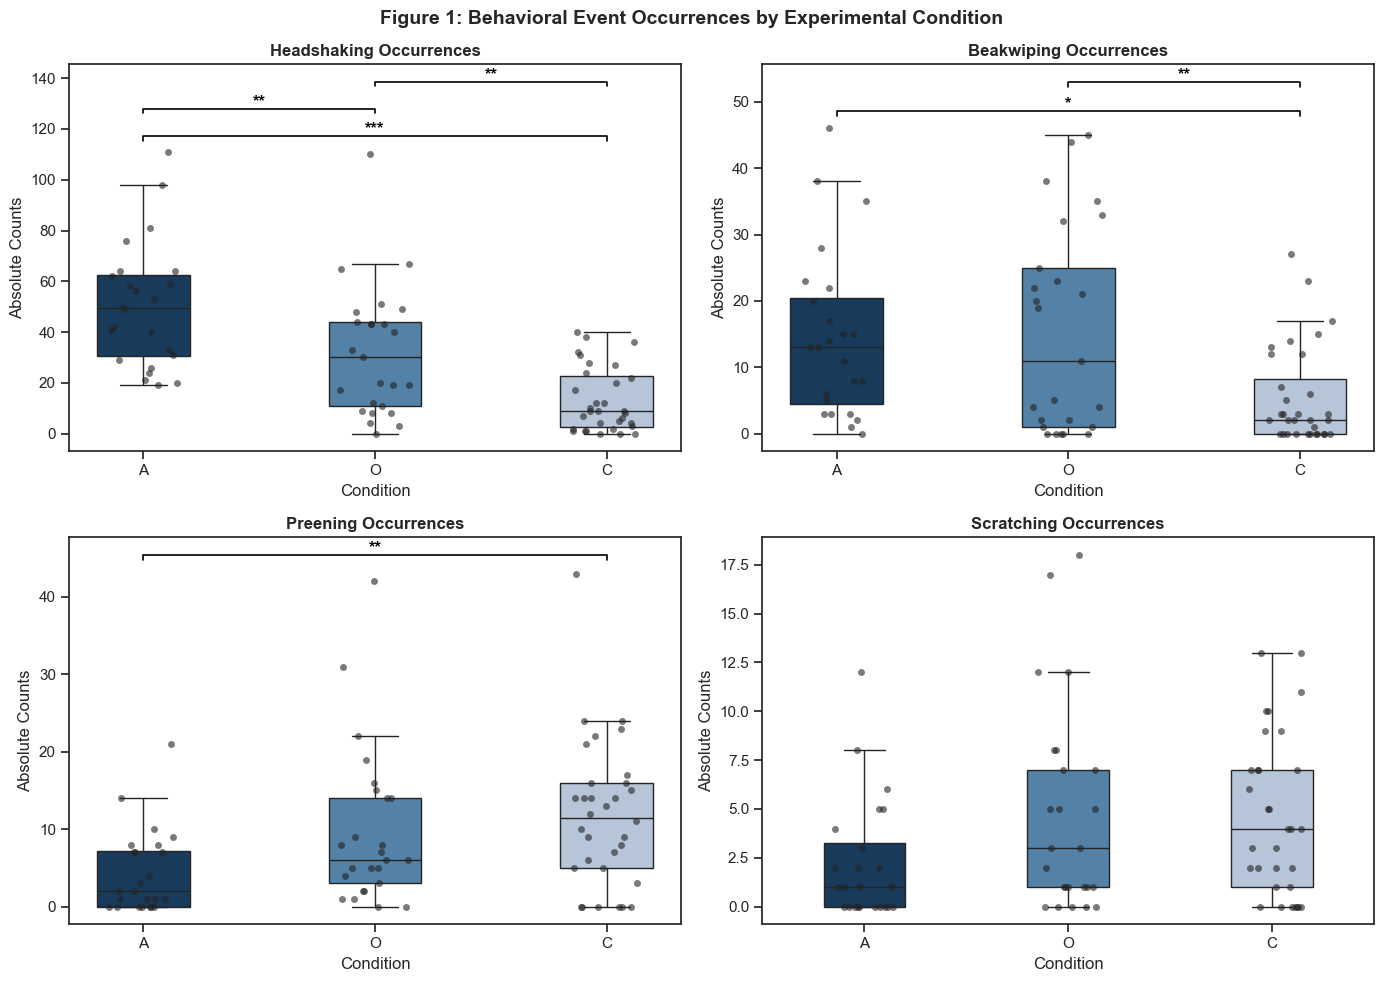

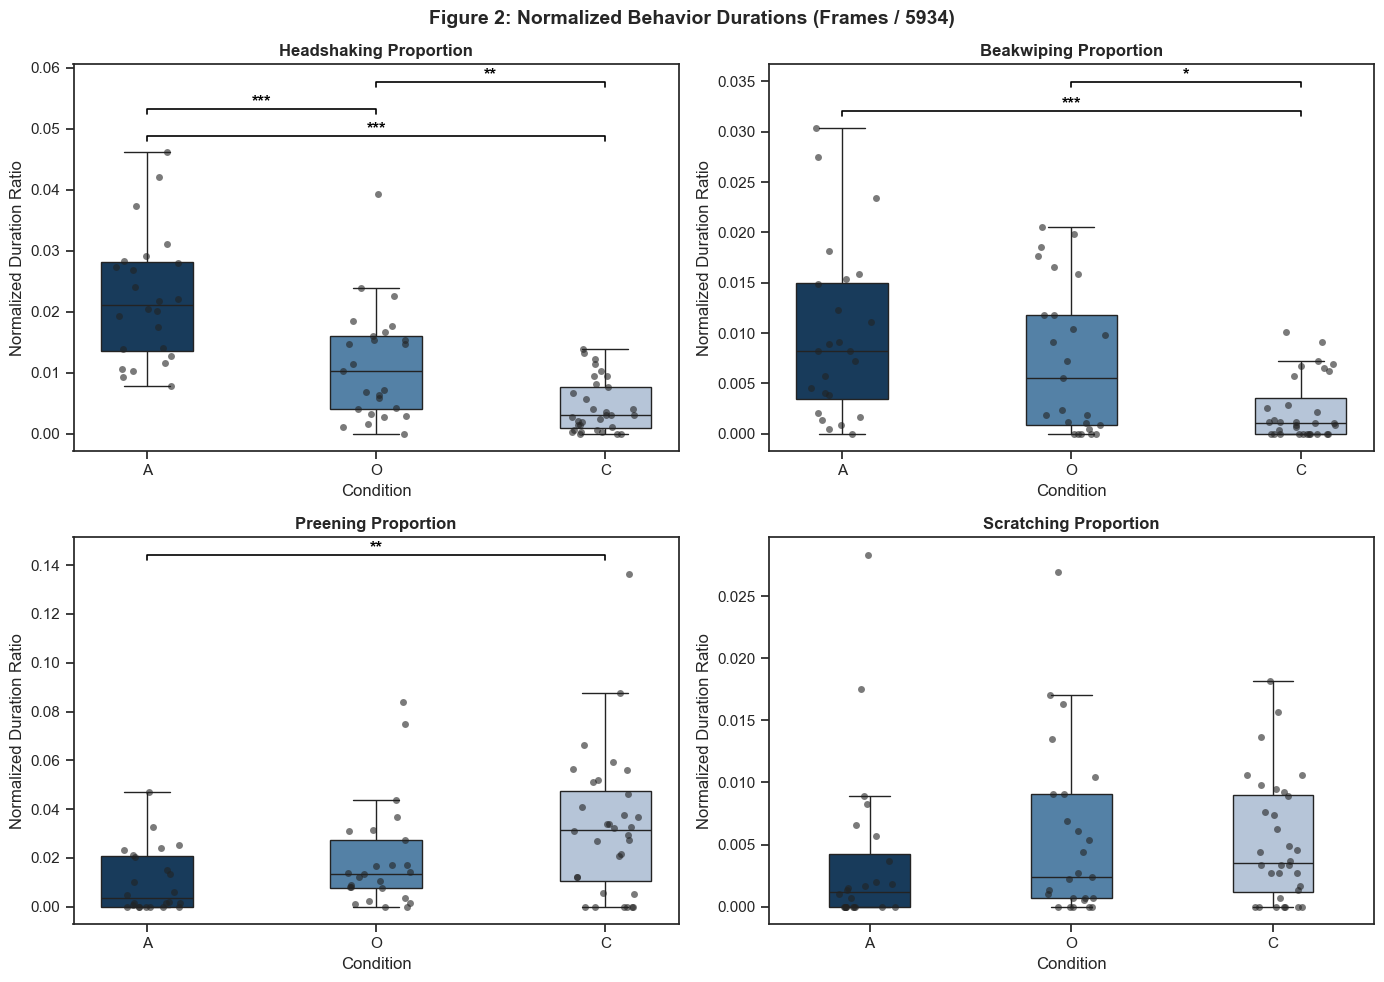

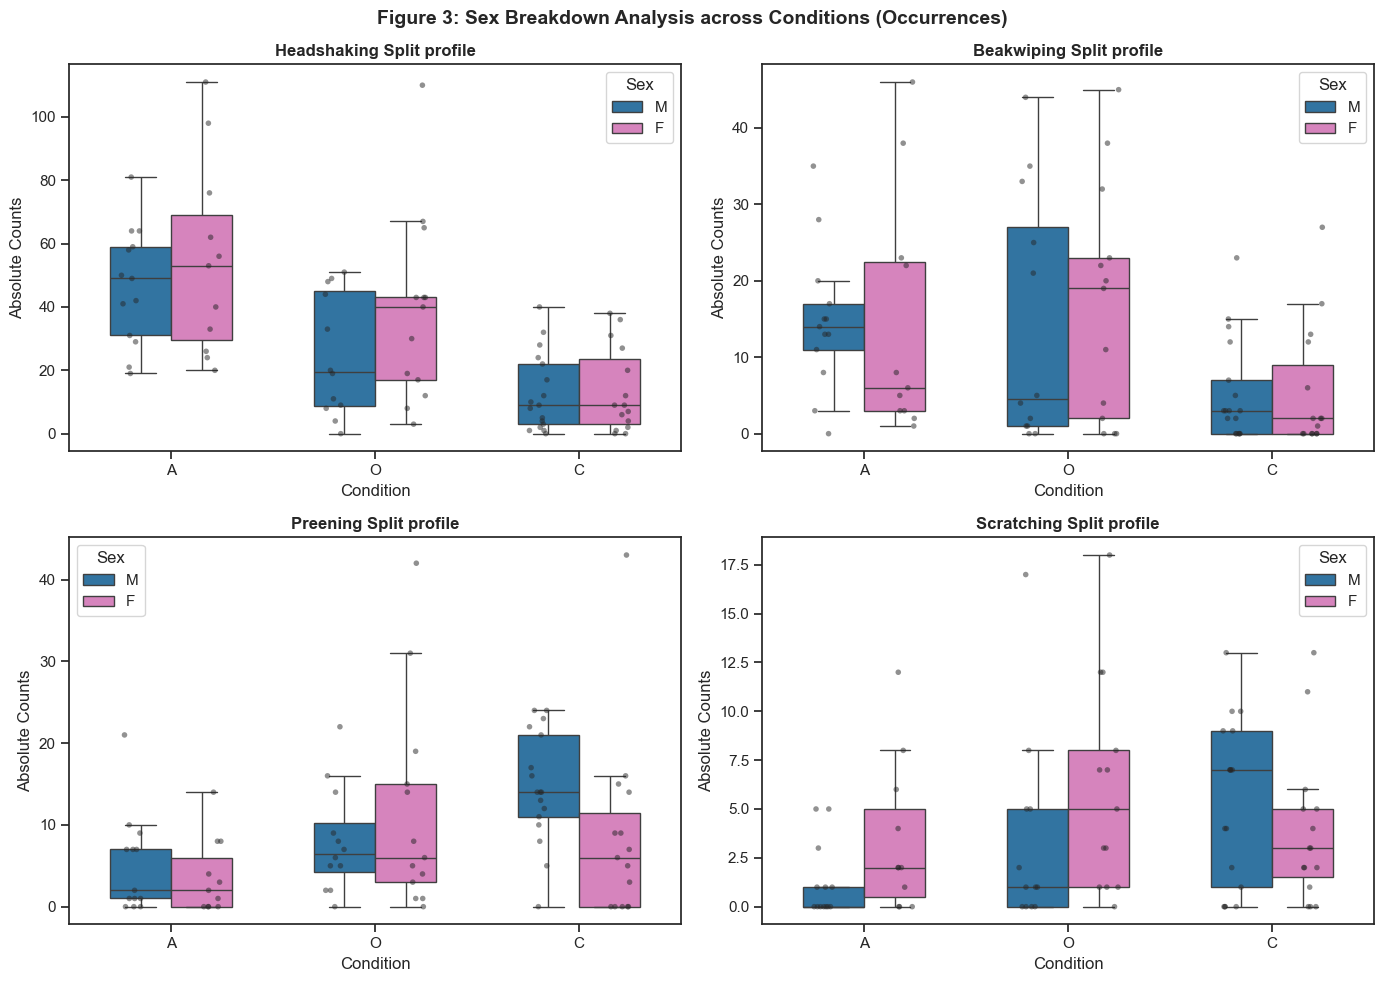

In [5]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

def annotate_significance(ax, behavior: str, tukey_results: dict, ordered_groups: list, data_df: pd.DataFrame, metric_col: str):
    """
    Programmatically calculates data height limits and overlays clean significance bars 
    using exact adjusted p-values from the Block 3 Tukey HSD outputs.
    """
    if not tukey_results or behavior not in tukey_results:
        return # Skip if no significance models exist or if it was omitted due to zero variance
        
    tukey_data = tukey_results[behavior]
    
    # Safely convert the statsmodels Tukey table object directly to a clean pandas DataFrame
    tk_df = pd.DataFrame(tukey_data.summary().data[1:], columns=tukey_data.summary().data[0])
    
    # Track plotting indices for 'A', 'O', 'C'
    group_positions = {group: idx for idx, group in enumerate(ordered_groups)}
    
    # Track annotation heights dynamically to prevent stacking overlaps
    max_y = data_df[metric_col].max()
    y_shift = (data_df[metric_col].max() - data_df[metric_col].min()) * 0.08
    if y_shift == 0: y_shift = 1.0
    
    current_annot_height = max_y + (y_shift * 0.5)
    
    for _, row in tk_df.iterrows():
        p_adj = float(row['p-adj'])
        if p_adj < 0.05:
            g1, g2 = str(row['group1']), str(row['group2'])
            if g1 in group_positions and g2 in group_positions:
                idx1 = group_positions[g1]
                idx2 = group_positions[g2]
                
                # Formulate asterisk marker
                if p_adj < 0.001: star = "***"
                elif p_adj < 0.01: star = "**"
                else: star = "*"
                
                # Draw bracket line parameters
                x1, x2 = idx1, idx2
                y, h = current_annot_height, y_shift * 0.2
                
                ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, color='black')
                ax.text((x1+x2)*0.5, y+h, star, ha='center', va='bottom', color='black', fontsize=12, fontweight='bold')
                
                # Advance stacking height ceiling for subsequent pairs
                current_annot_height += y_shift * 1.2

def generate_plots(df_behav: pd.DataFrame, df_frames: pd.DataFrame, tukey_b: dict, tukey_f: dict, config: dict):
    """
    Generates three high-resolution multi-panel figures containing hybrid 
    Boxplots/Stripplots matching your specified color palettes and structural order.
    """
    behaviors = config["BEHAVIORS"]
    cond_order = ['A', 'O', 'C']
    cond_palette = config["PLOT_SETTINGS"]["CONDITION_PALETTE"]
    sex_palette = config["PLOT_SETTINGS"]["SEX_PALETTE"]
    video_len = config["VIDEO_LENGTH_CONSTANT"]
    
    # Prepare dynamic frame normalization data
    df_durations = df_frames.copy()
    for behavior in behaviors:
        df_durations[behavior] = df_durations[behavior] / video_len

    sns.set_theme(style="ticks")
    
    # ---------------------------------------------------------------------
    # FIGURE 1: OCCURRENCES (df_behav) BY CONDITION
    # ---------------------------------------------------------------------
    fig1, axes1 = plt.subplots(2, 2, figsize=config["PLOT_SETTINGS"]["FIGURE_SIZE"], sharex=False)
    fig1.suptitle("Figure 1: Behavioral Event Occurrences by Experimental Condition", fontsize=14, fontweight='bold')
    
    for idx, behavior in enumerate(behaviors):
        ax = axes1[idx // 2, idx % 2]
        sns.boxplot(x='Condition', y=behavior, data=df_behav, order=cond_order, palette=cond_palette, ax=ax, width=0.4, fliersize=0)
        sns.stripplot(x='Condition', y=behavior, data=df_behav, order=cond_order, color='#222222', alpha=0.6, size=5, jitter=0.15, ax=ax)
        ax.set_title(f"{behavior} Occurrences", fontsize=12, fontweight='semibold')
        ax.set_xlabel("Condition")
        ax.set_ylabel("Absolute Counts")
        
        # Trigger dynamic significance bars
        annotate_significance(ax, behavior, tukey_b, cond_order, df_behav, behavior)
        
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------------------
    # FIGURE 2: DURATIONS (df_durations) BY CONDITION (NORMALIZED)
    # ---------------------------------------------------------------------
    fig2, axes2 = plt.subplots(2, 2, figsize=config["PLOT_SETTINGS"]["FIGURE_SIZE"], sharex=False)
    fig2.suptitle("Figure 2: Normalized Behavior Durations (Frames / 5934)", fontsize=14, fontweight='bold')
    
    for idx, behavior in enumerate(behaviors):
        ax = axes2[idx // 2, idx % 2]
        sns.boxplot(x='Condition', y=behavior, data=df_durations, order=cond_order, palette=cond_palette, ax=ax, width=0.4, fliersize=0)
        sns.stripplot(x='Condition', y=behavior, data=df_durations, order=cond_order, color='#222222', alpha=0.6, size=5, jitter=0.15, ax=ax)
        ax.set_title(f"{behavior} Proportion", fontsize=12, fontweight='semibold')
        ax.set_xlabel("Condition")
        ax.set_ylabel("Normalized Duration Ratio")
        
        # Trigger dynamic significance bars (using frames post-hoc values)
        annotate_significance(ax, behavior, tukey_f, cond_order, df_durations, behavior)
        
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------------------
    # FIGURE 3: SEX BREAKDOWN (df_behav Split Across Conditions)
    # ---------------------------------------------------------------------
    fig3, axes3 = plt.subplots(2, 2, figsize=config["PLOT_SETTINGS"]["FIGURE_SIZE"], sharex=False)
    fig3.suptitle("Figure 3: Sex Breakdown Analysis across Conditions (Occurrences)", fontsize=14, fontweight='bold')
    
    for idx, behavior in enumerate(behaviors):
        ax = axes3[idx // 2, idx % 2]
        sns.boxplot(x='Condition', y=behavior, hue='Sex', data=df_behav, order=cond_order, hue_order=['M', 'F'], palette=sex_palette, ax=ax, width=0.6, fliersize=0)
        sns.stripplot(x='Condition', y=behavior, hue='Sex', data=df_behav, order=cond_order, hue_order=['M', 'F'], dodge=True, color='#222222', alpha=0.5, size=4, ax=ax)
        
        ax.set_title(f"{behavior} Split profile", fontsize=12, fontweight='semibold')
        ax.set_xlabel("Condition")
        ax.set_ylabel("Absolute Counts")
        
        # Clean up double legend generation artifacts caused by combining boxplot and stripplot
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles[0:2], labels[0:2], title="Sex")
        
    plt.tight_layout()
    plt.show()

# =============================================================================
# EXECUTE BLOCK 4
# =============================================================================
generate_plots(df_behav, df_frames, tukey_behav_results, tukey_frames_results, CONFIG)